In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

PATH = r"../../data/Student_Performance.csv"
df = pd.read_csv(PATH)
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [55]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [57]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [58]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [59]:
df[df.astype(str).apply(lambda x: x.str.contains('\?')).any(axis=1)]

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
C:\Users\bigge\AppData\Local\Temp\ipykernel_7164\901282791.py:1: SyntaxWarning: invalid escape sequence '\?'
  df[df.astype(str).apply(lambda x: x.str.contains('\?')).any(axis=1)]


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [60]:
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


In [61]:
df['Hours Studied'].unique()

array([7, 4, 8, 5, 3, 6, 2, 1, 9])

In [62]:
df['Previous Scores'].unique()

array([99, 82, 51, 52, 75, 78, 73, 45, 77, 89, 91, 79, 47, 72, 83, 54, 96,
       74, 85, 61, 62, 84, 94, 90, 44, 70, 67, 97, 59, 55, 68, 63, 46, 76,
       43, 81, 93, 98, 48, 92, 64, 88, 60, 87, 40, 69, 80, 95, 49, 50, 53,
       71, 56, 58, 66, 65, 57, 41, 42, 86])

In [63]:
df.drop_duplicates(inplace=True)

In [64]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


In [67]:
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
y = df['Performance Index']
X = df.drop(columns='Performance Index')

X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.2, random_state=42)

In [70]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [71]:
y_predict = model.predict(X_test)

In [72]:
mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
rmse = np.sqrt(mse) # note : (rmse) ()
r2 = r2_score(y_test,y_predict)

print("Linear Regression Results")
print("mae :", mae)
print(f"mse :",mse)
print(f"rmse :",rmse)
print(f"r2 :",r2)

Linear Regression Results
mae : 1.6469703984255568
mse : 4.305900938538477
rmse : 2.0750664901488043
r2 : 0.9884301209927054


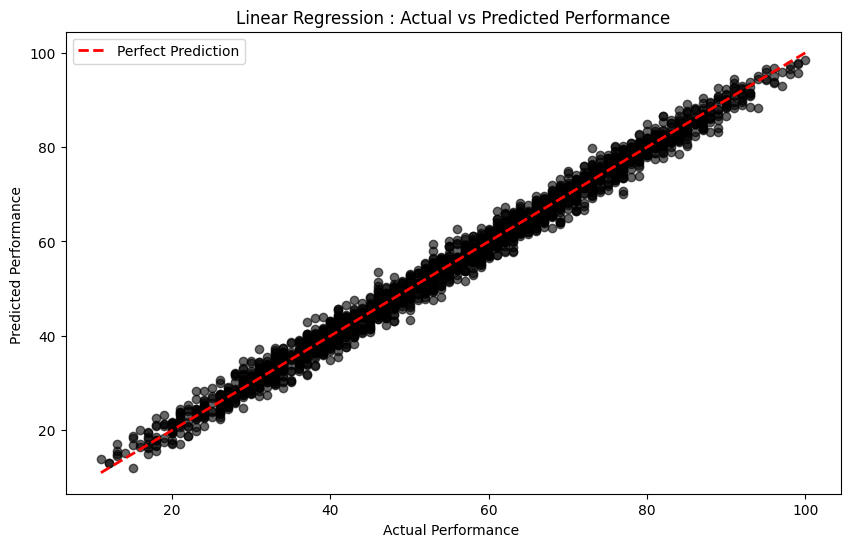

In [73]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, color='black', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("Linear Regression : Actual vs Predicted Performance")
plt.legend()
plt.show()

In [74]:
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [75]:
np.sort(y_predict)

array([12.06131529, 13.00483359, 13.07974563, ..., 97.50595086,
       97.81615812, 98.36251517], shape=(1975,))

In [76]:
mae_pol= mean_absolute_error(y_test, y_pred_poly)
mse_pol = mean_squared_error(y_test, y_pred_poly)
rmse_pol = np.sqrt(mse_pol)
r2_pol = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results Degree 2")
print("Mean Absolute Error (MAE):", mae_pol)
print("Mean Squared Error (MSE):",mse_pol)
print("Root Mean Squared Error (RMSE):", rmse_pol)
print("R-squared (R2):", r2_pol)

Polynomial Regression Results Degree 2
Mean Absolute Error (MAE): 1.646786075115477
Mean Squared Error (MSE): 4.305196231740646
Root Mean Squared Error (RMSE): 2.0748966797748376
R-squared (R2): 0.9884320145272997


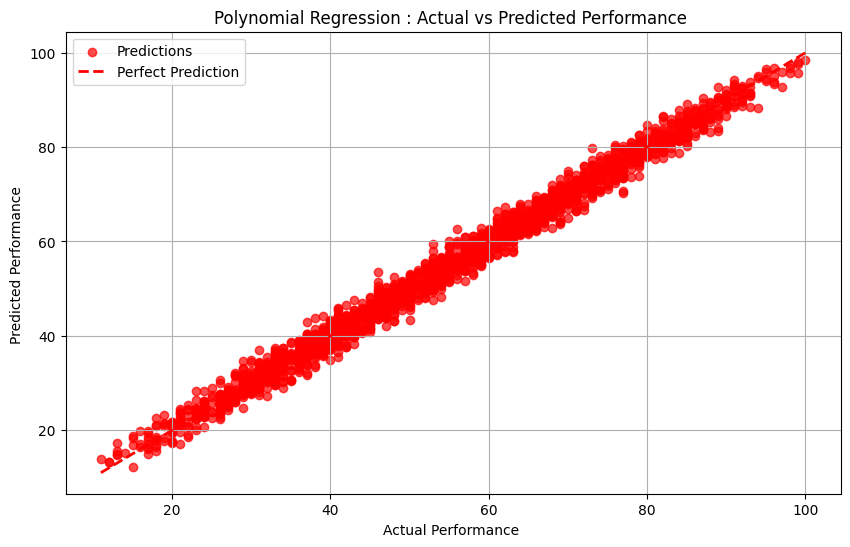

In [77]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, color='red', alpha=0.7, label='Predictions')

min_value = min(y_test.min(), 
                y_pred_poly.min())
max_value = max(y_test.max(), 
                y_pred_poly.max())

plt.plot([min_value, max_value], 
         [min_value, max_value],

         color='red', linestyle='--', 

         linewidth=2,

           label='Perfect Prediction')


plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("Polynomial Regression : Actual vs Predicted Performance ")
plt.grid(True)
plt.legend()
plt.show()

In [78]:
from sklearn.linear_model import Lasso

In [79]:
lasso_model = Lasso(alpha=0.1)


lasso_model.fit(X_train, y_train)


y_pred_lasso = lasso_model.predict(X_test)


mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(" Lasso Regression Results ")
print("Mean Absolute Error (MAE): ",mae_lasso)
print("Mean Squared Error (MSE): ",mse_lasso)
print("Root Mean Squared Error (RMSE): ",rmse_lasso)
print("R-squared (R2): ",r2_lasso)

 Lasso Regression Results 
Mean Absolute Error (MAE):  1.6675797579683809
Mean Squared Error (MSE):  4.410175268700736
Root Mean Squared Error (RMSE):  2.1000417302284107
R-squared (R2):  0.9881499377277477


C:\Users\bigge\AppData\Local\Temp\ipykernel_7164\2908550319.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


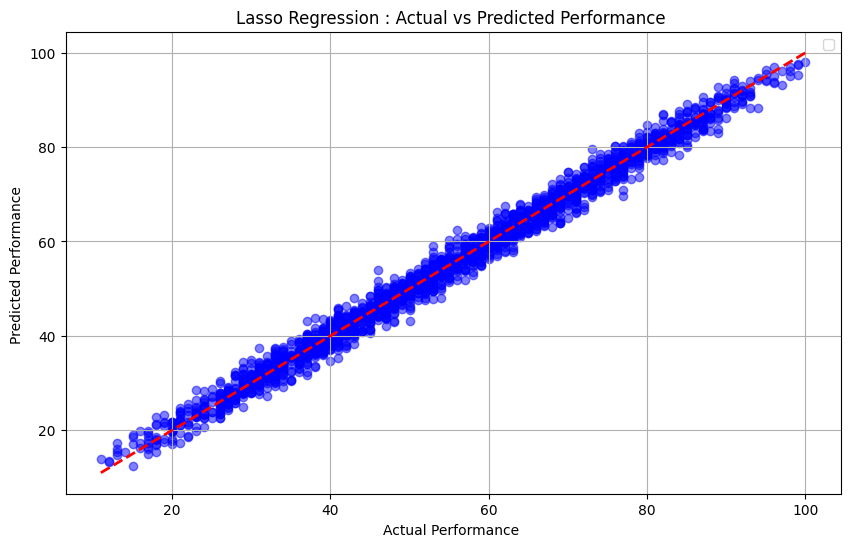

In [80]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lasso, color='blue', alpha=0.5,)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2,)

plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("Lasso Regression : Actual vs Predicted Performance ")
plt.grid(True)
plt.legend()
plt.show()

In [81]:
from sklearn.linear_model import Ridge


ridge_model = Ridge(alpha=1.0)


ridge_model.fit(X_train, y_train)


y_pred_ridge = ridge_model.predict(X_test)

In [82]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results ")
print("Mean Absolute Error (MAE): ",mae_ridge)
print("Mean Squared Error (MSE): ",mse_ridge)
print("Root Mean Squared Error (RMSE):",rmse_ridge)
print("R-squared (R2): ",r2_ridge)

Ridge Regression Results 
Mean Absolute Error (MAE):  1.6469786994875084
Mean Squared Error (MSE):  4.3059442136375745
Root Mean Squared Error (RMSE): 2.0750769175231976
R-squared (R2):  0.9884300047132861


C:\Users\bigge\AppData\Local\Temp\ipykernel_7164\1075260320.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


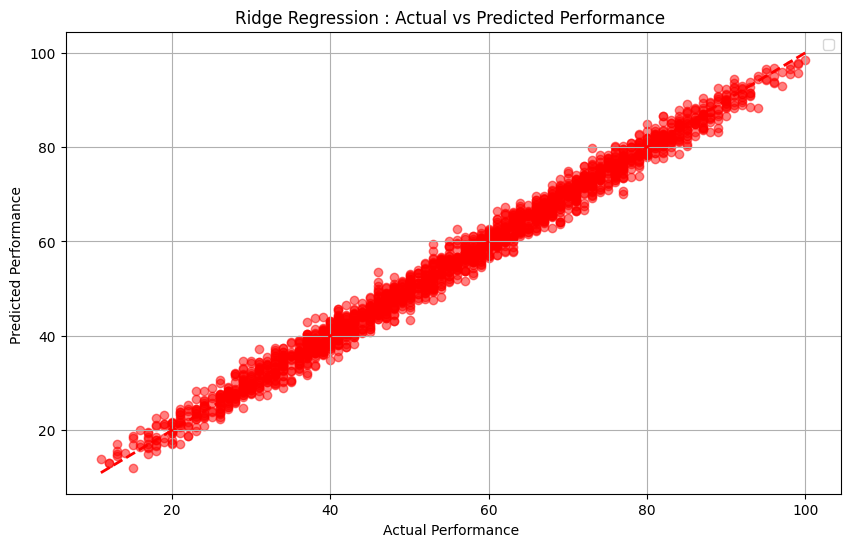

In [83]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ridge, color='red', alpha=0.5,)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2,)

plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("Ridge Regression : Actual vs Predicted Performance ")
plt.grid(True)
plt.legend()
plt.show()

In [84]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=10, random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [85]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results ")
print("Mean Absolute Error (MAE): ",mae_tree)
print("Mean Squared Error (MSE): ",mse_tree)
print("Root Mean Squared Error (RMSE): ",rmse_tree)
print("R-squared (R2): ",r2_tree)

Decision Tree Results 
Mean Absolute Error (MAE):  2.042195232915738
Mean Squared Error (MSE):  6.613062887936689
Root Mean Squared Error (RMSE):  2.5715876201165475
R-squared (R2):  0.9822308179929872


C:\Users\bigge\AppData\Local\Temp\ipykernel_7164\4036249311.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


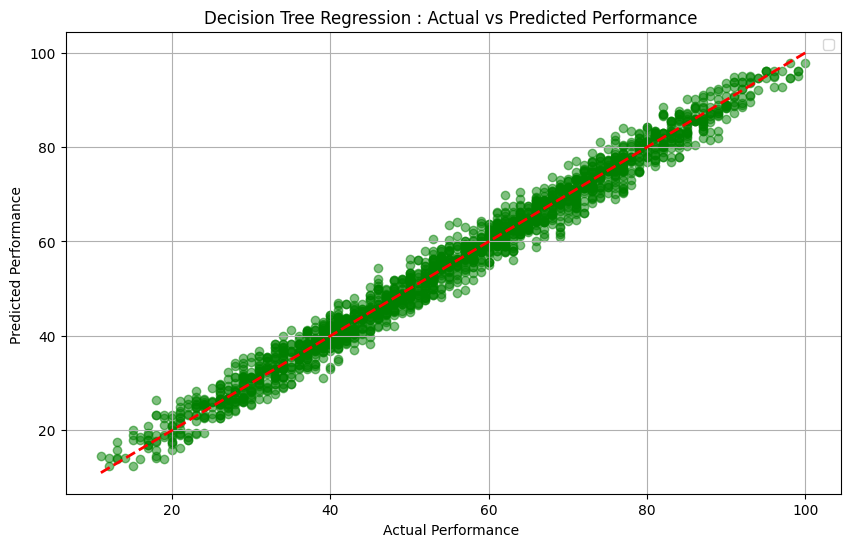

In [86]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tree, color='green', alpha=0.5,)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2,)

plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("Decision Tree Regression : Actual vs Predicted Performance ")
plt.grid(True)
plt.legend()
plt.show()

In [87]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=500, max_depth=None, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [88]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results ")
print("Mean Absolute Error (MAE): ",mae_rf)
print("Mean Squared Error (MSE): ",mse_rf)
print("Root Mean Squared Error (RMSE): ",rmse_rf)
print("R-squared (R2): ",r2_rf)

Random Forest Results 
Mean Absolute Error (MAE):  1.8948945924708203
Mean Squared Error (MSE):  5.598728737545605
Root Mean Squared Error (RMSE):  2.3661632947760824
R-squared (R2):  0.9849563157600062


C:\Users\bigge\AppData\Local\Temp\ipykernel_7164\2356304250.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


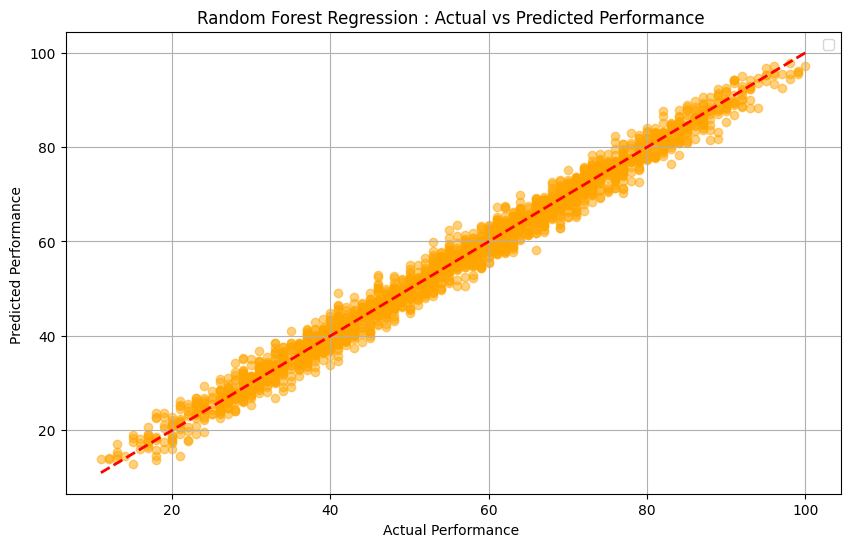

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='orange', alpha=0.5,)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2,)

plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("Random Forest Regression : Actual vs Predicted Performance ")
plt.grid(True)
plt.legend()
plt.show()

In [90]:
from sklearn.svm import SVR


svm_model = SVR(kernel='rbf', C=100, epsilon=0.1)

svm_model.fit(X_train, y_train)

y_pred_svr = svm_model.predict(X_test)

In [91]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVM Regression Results ")
print("Mean Absolute Error (MAE): ",mae_svr)
print("Mean Squared Error (MSE): ",mse_svr)
print("Root Mean Squared Error (RMSE): ",rmse_svr)
print("R-squared (R2): ",r2_svr)

SVM Regression Results 
Mean Absolute Error (MAE):  1.6523967670936548
Mean Squared Error (MSE):  4.342587882389299
Root Mean Squared Error (RMSE):  2.083887684686797
R-squared (R2):  0.9883315438290502


C:\Users\bigge\AppData\Local\Temp\ipykernel_7164\641809829.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


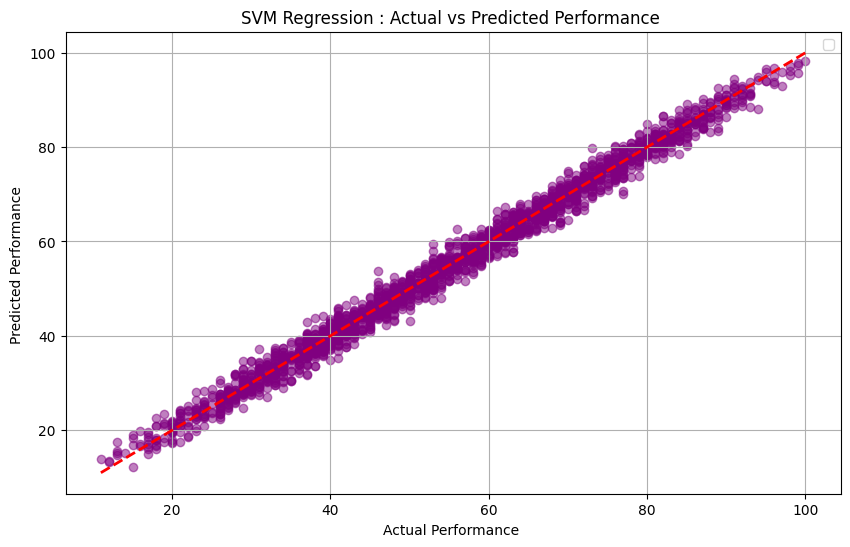

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svr, color='purple', alpha=0.5,)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2,)

plt.xlabel("Actual Performance ")
plt.ylabel("Predicted Performance ")
plt.title("SVM Regression : Actual vs Predicted Performance ")
plt.grid(True)
plt.legend()
plt.show()